In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
df = pd.read_excel('employees_data.xlsx')
df.head(5)

,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556,2,High School,5,6750,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556,0,High School,5,7500,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556,8,High School,3,5850,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556,7,Bachelor,2,4800,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556,3,Bachelor,2,4800,38,11,29,13,100,15,9,1,1.25,False


In [16]:
# basic overview
print(f"shape:{df.shape}")
print(f"rows:{df.shape[0]},columns:{df.shape[1]}")
df.head()

shape:(100000, 20)
rows:100000,columns:20


,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556,2,High School,5,6750,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556,0,High School,5,7500,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556,8,High School,3,5850,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556,7,Bachelor,2,4800,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556,3,Bachelor,2,4800,38,11,29,13,100,15,9,1,1.25,False


In [17]:
# columns name and data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   Employee_ID                  100000 non-null  int64         
 1   Department                   100000 non-null  object        
 2   Gender                       100000 non-null  object        
 3   Age                          100000 non-null  int64         
 4   Job_Title                    100000 non-null  object        
 5   Hire_Date                    100000 non-null  datetime64[ns]
 6   Years_At_Company             100000 non-null  int64         
 7   Education_Level              100000 non-null  object        
 8   Performance_Score            100000 non-null  int64         
 9   Monthly_Salary               100000 non-null  int64         
 10  Work_Hours_Per_Week          100000 non-null  int64         
 11  Projects_Handled           

In [20]:
# Missing values:
missing = pd.DataFrame({
    'missing count': df.isnull().sum(),
    'missing %': (df.isnull().sum()/len(df)*100).round(2)
})
print(missing[missing['missing count']>0])

Empty DataFrame
Columns: [missing count, missing %]
Index: []


In [22]:
# Duplicates:
print(f'Duplicate rows: {df.duplicated().sum()}')
print(f'Duplicate Employee IDs: {df["Employee_ID"].duplicated().sum()}')

Duplicate rows: 0
Duplicate Employee IDs: 0


In [23]:
# Text columns consistency check:
cat_cols = ['Department', 'Gender', 'Job_Title', 'Education_Level']
for col in cat_cols:
    print(f'\n{col} unique values: {df[col].nunique()}')
    print(df[col].value_counts())


Department unique values: 9
Department
Marketing           11216
Finance             11200
Operations          11181
IT                  11131
Sales               11122
Legal               11118
Customer Support    11116
HR                  10960
Engineering         10956
Name: count, dtype: int64

Gender unique values: 3
Gender
Male      48031
Female    48001
Other      3968
Name: count, dtype: int64

Job_Title unique values: 7
Job_Title
Specialist    14507
Manager       14325
Technician    14285
Analyst       14261
Engineer      14217
Consultant    14210
Developer     14195
Name: count, dtype: int64

Education_Level unique values: 4
Education_Level
Bachelor       50041
High School    30004
Master         14904
PhD             5051
Name: count, dtype: int64


In [24]:
# Numeric ranges check (outliers ya invalid values):
print(df[['Age', 'Monthly_Salary', 'Work_Hours_Per_Week', 
          'Performance_Score', 'Employee_Satisfaction_Score',
          'Years_At_Company', 'Overtime_Hours']].describe().round(2))

             Age  Monthly_Salary  Work_Hours_Per_Week  Performance_Score  \
count  100000.00       100000.00            100000.00          100000.00   
mean       41.03         6403.21                44.96               3.00   
std        11.24         1372.51                 8.94               1.41   
min        22.00         3850.00                30.00               1.00   
25%        31.00         5250.00                37.00               2.00   
50%        41.00         6500.00                45.00               3.00   
75%        51.00         7500.00                53.00               4.00   
max        60.00         9000.00                60.00               5.00   

       Employee_Satisfaction_Score  Years_At_Company  Overtime_Hours  
count                    100000.00         100000.00       100000.00  
mean                          3.00              4.48           14.51  
std                           1.15              2.87            8.66  
min                           1

In [25]:
# Extra columns :

# 1. Attrition label
df['Attrition'] = df['Resigned'].map({True: 'Yes', False: 'No'})

In [26]:
# 2. Age Group
df['Age_Group'] = pd.cut(df['Age'], 
    bins=[21, 25, 30, 35, 40, 45, 50, 60],
    labels=['22-25', '26-30', '31-35', '36-40', '41-45', '46-50', '51-60'])

In [27]:
# 3. Tenure Group
df['Tenure_Group'] = pd.cut(df['Years_At_Company'],
    bins=[-1, 1, 2, 5, 10],
    labels=['0-1 Yr', '1-2 Yrs', '2-5 Yrs', '5-10 Yrs'])

In [28]:
# 4. Performance Category
df['Performance_Category'] = df['Performance_Score'].map({
    1: 'Poor', 2: 'Below Average', 3: 'Average', 4: 'Good', 5: 'Excellent'})

In [29]:
# 5. Salary Band
df['Salary_Band'] = pd.cut(df['Monthly_Salary'],
    bins=[3849, 5000, 6500, 7500, 9001],
    labels=['Entry', 'Mid', 'Senior', 'Executive'])

In [30]:
# 6. Hire Year
df['Hire_Year'] = df['Hire_Date'].dt.year

print('Columns ban gaye!')
print(df[['Attrition', 'Age_Group', 'Tenure_Group', 
          'Performance_Category', 'Salary_Band', 'Hire_Year']].head(10))

Columns ban gaye!
  Attrition Age_Group Tenure_Group Performance_Category Salary_Band  Hire_Year
0        No     51-60      1-2 Yrs            Excellent      Senior       2022
1        No     26-30       0-1 Yr            Excellent      Senior       2024
2        No     51-60     5-10 Yrs              Average         Mid       2015
3        No     46-50     5-10 Yrs        Below Average       Entry       2016
4        No     36-40      2-5 Yrs        Below Average       Entry       2021
5        No     41-45     5-10 Yrs              Average   Executive       2016
6        No     36-40       0-1 Yr            Excellent         Mid       2023
7        No     51-60     5-10 Yrs        Below Average      Senior       2014
8        No     51-60       0-1 Yr        Below Average       Entry       2023
9        No     41-45     5-10 Yrs                 Poor         Mid       2016


In [31]:
# verifying 
print(f'Total columns: {df.shape[1]}')
print(f'\nAttrition split:\n{df["Attrition"].value_counts()}')
print(f'\nAge_Group split:\n{df["Age_Group"].value_counts().sort_index()}')
print(f'\nTenure_Group split:\n{df["Tenure_Group"].value_counts().sort_index()}')
print(f'\nPerformance_Category:\n{df["Performance_Category"].value_counts()}')
print(f'\nSalary_Band:\n{df["Salary_Band"].value_counts().sort_index()}')

Total columns: 26

Attrition split:
Attrition
No     89990
Yes    10010
Name: count, dtype: int64

Age_Group split:
Age_Group
22-25    10178
26-30    12853
31-35    12704
36-40    12831
41-45    12756
46-50    12965
51-60    25713
Name: count, dtype: int64

Tenure_Group split:
Tenure_Group
0-1 Yr      20101
1-2 Yrs     10272
2-5 Yrs     29930
5-10 Yrs    39697
Name: count, dtype: int64

Performance_Category:
Performance_Category
Poor             20120
Below Average    20013
Average          19999
Good             19940
Excellent        19928
Name: count, dtype: int64

Salary_Band:
Salary_Band
Entry        20129
Mid          31440
Senior       25571
Executive    22860
Name: count, dtype: int64


In [32]:
# save file 
df.to_excel('employee_clean_powerbi.xlsx', index=False)
print('File save ho gayi: employee_clean_powerbi.xlsx')
print(f'Total rows: {df.shape[0]}')
print(f'Total columns: {df.shape[1]}')
print('\nAb Power BI mein import karo!')

File save ho gayi: employee_clean_powerbi.xlsx
Total rows: 100000
Total columns: 26

Ab Power BI mein import karo!


In [33]:
# Overall Key Stats:
print('='*45)
print('        EMPLOYEE DATASET — KEY STATS')
print('='*45)
print(f'Total Employees      : {len(df):,}')
print(f'Departments          : {df["Department"].nunique()}')
print(f'Job Titles           : {df["Job_Title"].nunique()}')
print(f'Attrition Rate       : {df["Resigned"].mean()*100:.1f}%')
print(f'Avg Monthly Salary   : Rs {df["Monthly_Salary"].mean():,.0f}')
print(f'Avg Age              : {df["Age"].mean():.1f} years')
print(f'Avg Tenure           : {df["Years_At_Company"].mean():.1f} years')
print(f'Avg Performance      : {df["Performance_Score"].mean():.2f} / 5')
print(f'Avg Satisfaction     : {df["Employee_Satisfaction_Score"].mean():.2f} / 5')
print(f'Avg Training Hours   : {df["Training_Hours"].mean():.1f}')
print(f'Avg Overtime Hours   : {df["Overtime_Hours"].mean():.1f}')
print('='*45)

        EMPLOYEE DATASET — KEY STATS
Total Employees      : 100,000
Departments          : 9
Job Titles           : 7
Attrition Rate       : 10.0%
Avg Monthly Salary   : Rs 6,403
Avg Age              : 41.0 years
Avg Tenure           : 4.5 years
Avg Performance      : 3.00 / 5
Avg Satisfaction     : 3.00 / 5
Avg Training Hours   : 49.5
Avg Overtime Hours   : 14.5


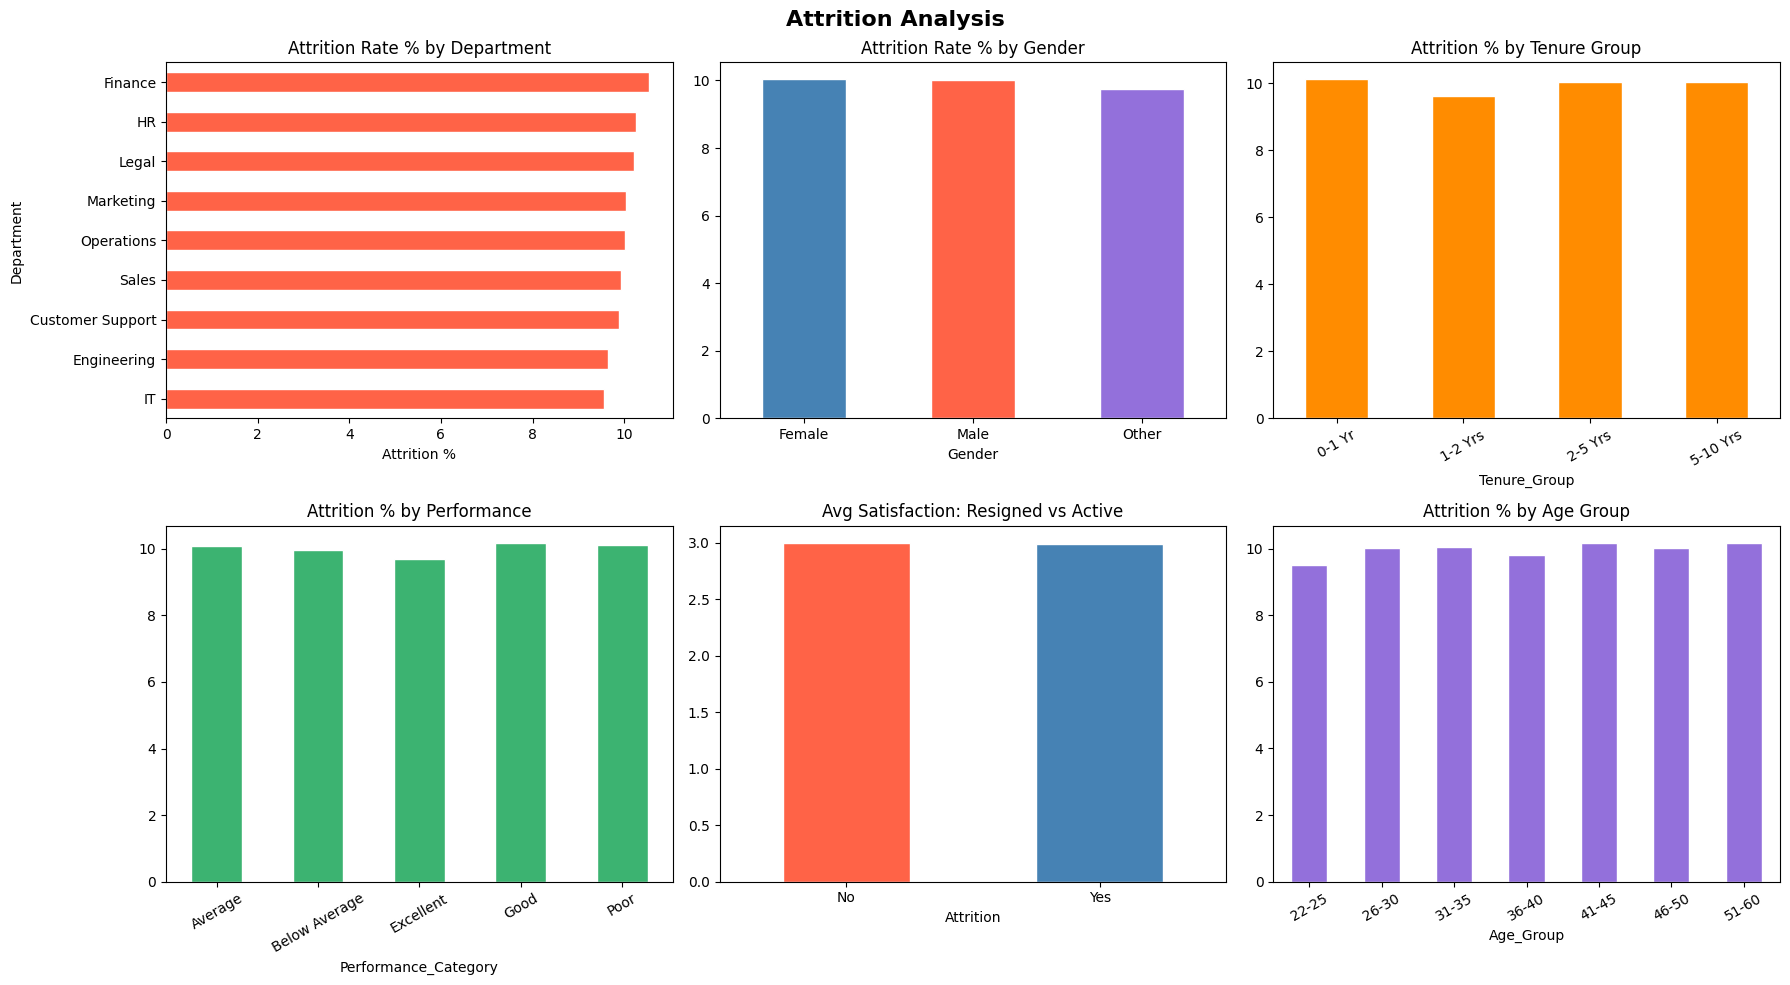

In [34]:
# Attrition Analysis (sabse important):
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Attrition Analysis', fontsize=16, fontweight='bold')

# 1. Attrition by Department
dept_att = df.groupby('Department')['Resigned'].mean()*100
dept_att.sort_values(ascending=True).plot(
    kind='barh', ax=axes[0,0], color='tomato', edgecolor='white')
axes[0,0].set_title('Attrition Rate % by Department')
axes[0,0].set_xlabel('Attrition %')

# 2. Attrition by Gender
gender_att = df.groupby('Gender')['Resigned'].mean()*100
gender_att.plot(kind='bar', ax=axes[0,1], 
    color=['steelblue','tomato','mediumpurple'], edgecolor='white')
axes[0,1].set_title('Attrition Rate % by Gender')
axes[0,1].tick_params(axis='x', rotation=0)

# 3. Attrition by Tenure Group
tenure_att = df.groupby('Tenure_Group', observed=True)['Resigned'].mean()*100
tenure_att.plot(kind='bar', ax=axes[0,2], color='darkorange', edgecolor='white')
axes[0,2].set_title('Attrition % by Tenure Group')
axes[0,2].tick_params(axis='x', rotation=30)

# 4. Attrition by Performance Category
perf_att = df.groupby('Performance_Category', observed=True)['Resigned'].mean()*100
perf_att.plot(kind='bar', ax=axes[1,0], color='mediumseagreen', edgecolor='white')
axes[1,0].set_title('Attrition % by Performance')
axes[1,0].tick_params(axis='x', rotation=30)

# 5. Satisfaction Score — Resigned vs Active
df.groupby('Attrition')['Employee_Satisfaction_Score'].mean().plot(
    kind='bar', ax=axes[1,1], color=['tomato','steelblue'], edgecolor='white')
axes[1,1].set_title('Avg Satisfaction: Resigned vs Active')
axes[1,1].tick_params(axis='x', rotation=0)

# 6. Attrition by Age Group
age_att = df.groupby('Age_Group', observed=True)['Resigned'].mean()*100
age_att.plot(kind='bar', ax=axes[1,2], color='mediumpurple', edgecolor='white')
axes[1,2].set_title('Attrition % by Age Group')
axes[1,2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

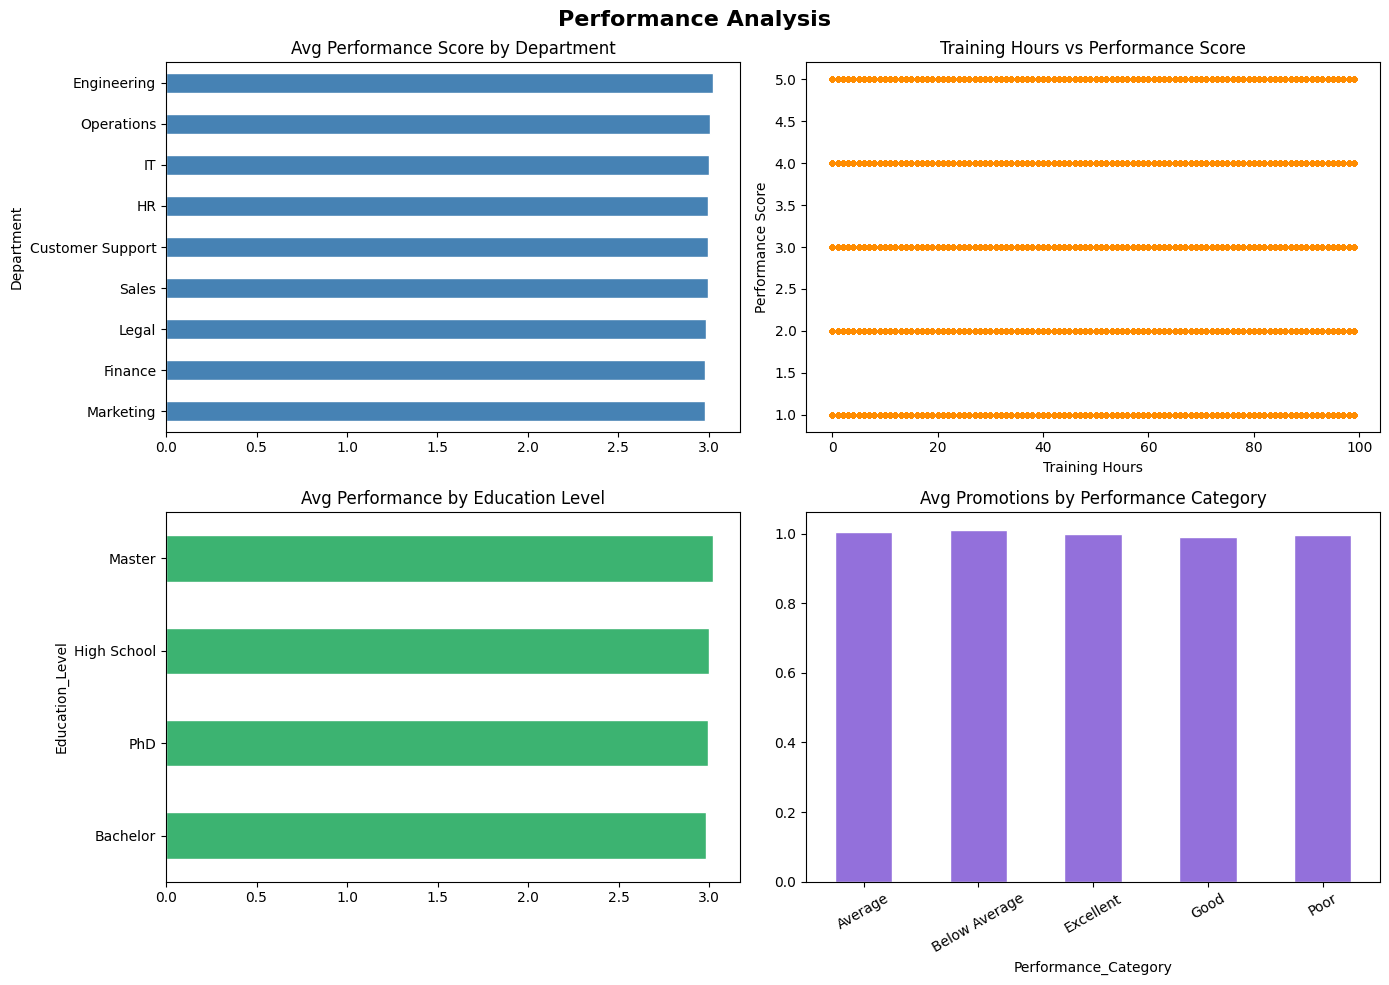

In [35]:
# Performance Analysis:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Performance Analysis', fontsize=16, fontweight='bold')

# 1. Avg Performance by Department
df.groupby('Department')['Performance_Score'].mean().sort_values(ascending=True).plot(
    kind='barh', ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('Avg Performance Score by Department')

# 2. Training Hours vs Performance Score
axes[0,1].scatter(df['Training_Hours'], df['Performance_Score'],
    alpha=0.2, color='darkorange', s=8)
axes[0,1].set_title('Training Hours vs Performance Score')
axes[0,1].set_xlabel('Training Hours')
axes[0,1].set_ylabel('Performance Score')

# 3. Performance by Education Level
df.groupby('Education_Level')['Performance_Score'].mean().sort_values(ascending=True).plot(
    kind='barh', ax=axes[1,0], color='mediumseagreen', edgecolor='white')
axes[1,0].set_title('Avg Performance by Education Level')

# 4. Promotions vs Performance
df.groupby('Performance_Category', observed=True)['Promotions'].mean().plot(
    kind='bar', ax=axes[1,1], color='mediumpurple', edgecolor='white')
axes[1,1].set_title('Avg Promotions by Performance Category')
axes[1,1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

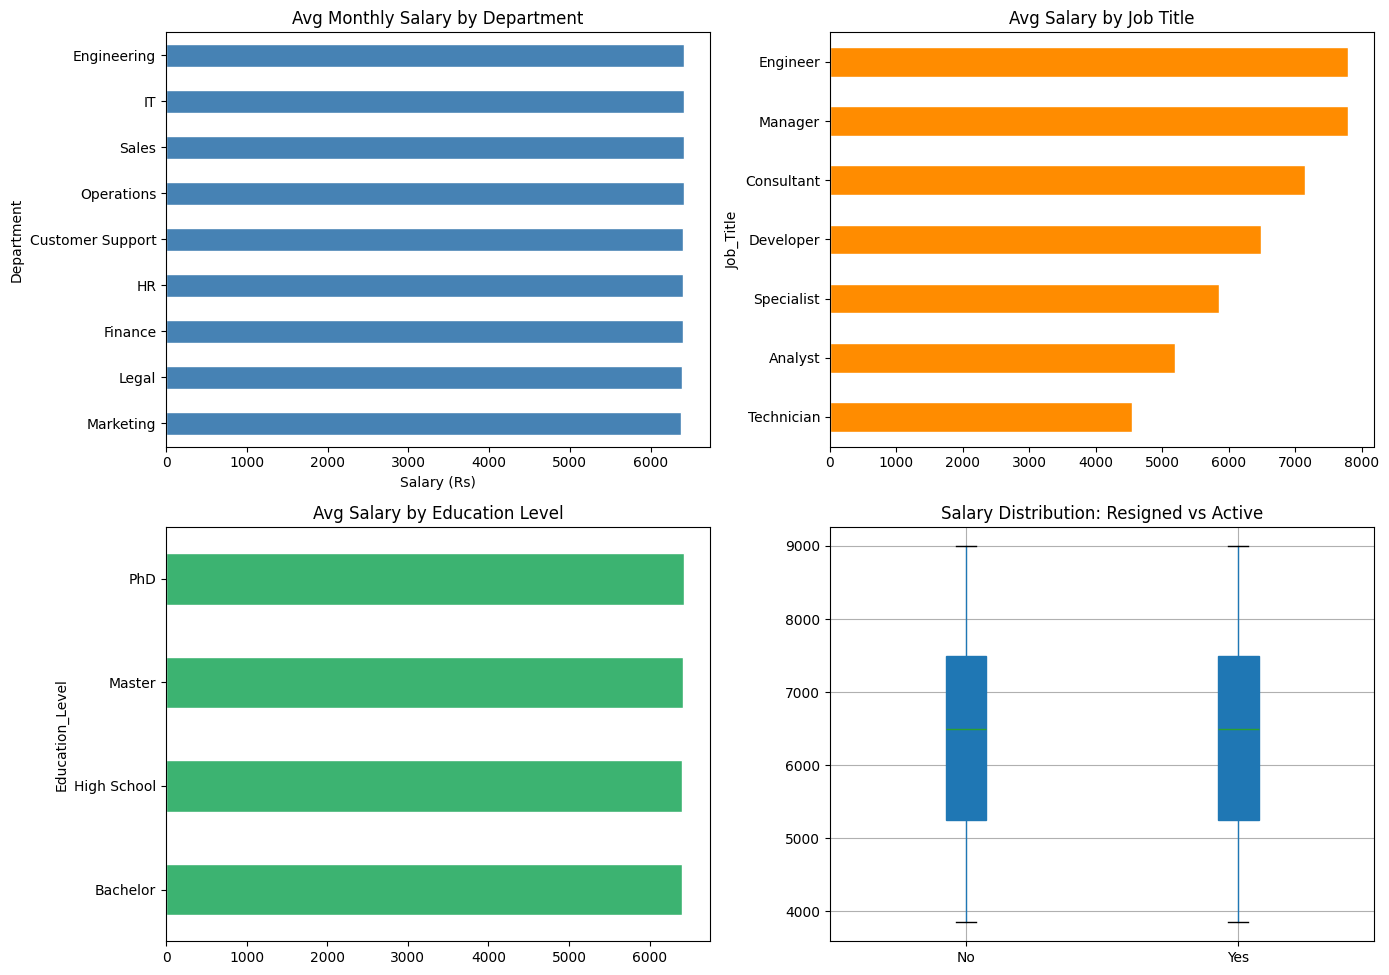

In [36]:
# Salary Analysis:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Salary Analysis', fontsize=16, fontweight='bold')

# 1. Avg Salary by Department
df.groupby('Department')['Monthly_Salary'].mean().sort_values(ascending=True).plot(
    kind='barh', ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('Avg Monthly Salary by Department')
axes[0,0].set_xlabel('Salary (Rs)')

# 2. Avg Salary by Job Title
df.groupby('Job_Title')['Monthly_Salary'].mean().sort_values(ascending=True).plot(
    kind='barh', ax=axes[0,1], color='darkorange', edgecolor='white')
axes[0,1].set_title('Avg Salary by Job Title')

# 3. Salary by Education Level
df.groupby('Education_Level')['Monthly_Salary'].mean().sort_values(ascending=True).plot(
    kind='barh', ax=axes[1,0], color='mediumseagreen', edgecolor='white')
axes[1,0].set_title('Avg Salary by Education Level')

# 4. Salary distribution — Resigned vs Active
df.boxplot(column='Monthly_Salary', by='Attrition', ax=axes[1,1],
    patch_artist=True)
axes[1,1].set_title('Salary Distribution: Resigned vs Active')
axes[1,1].set_xlabel('')
plt.suptitle('')

plt.tight_layout()
plt.show()

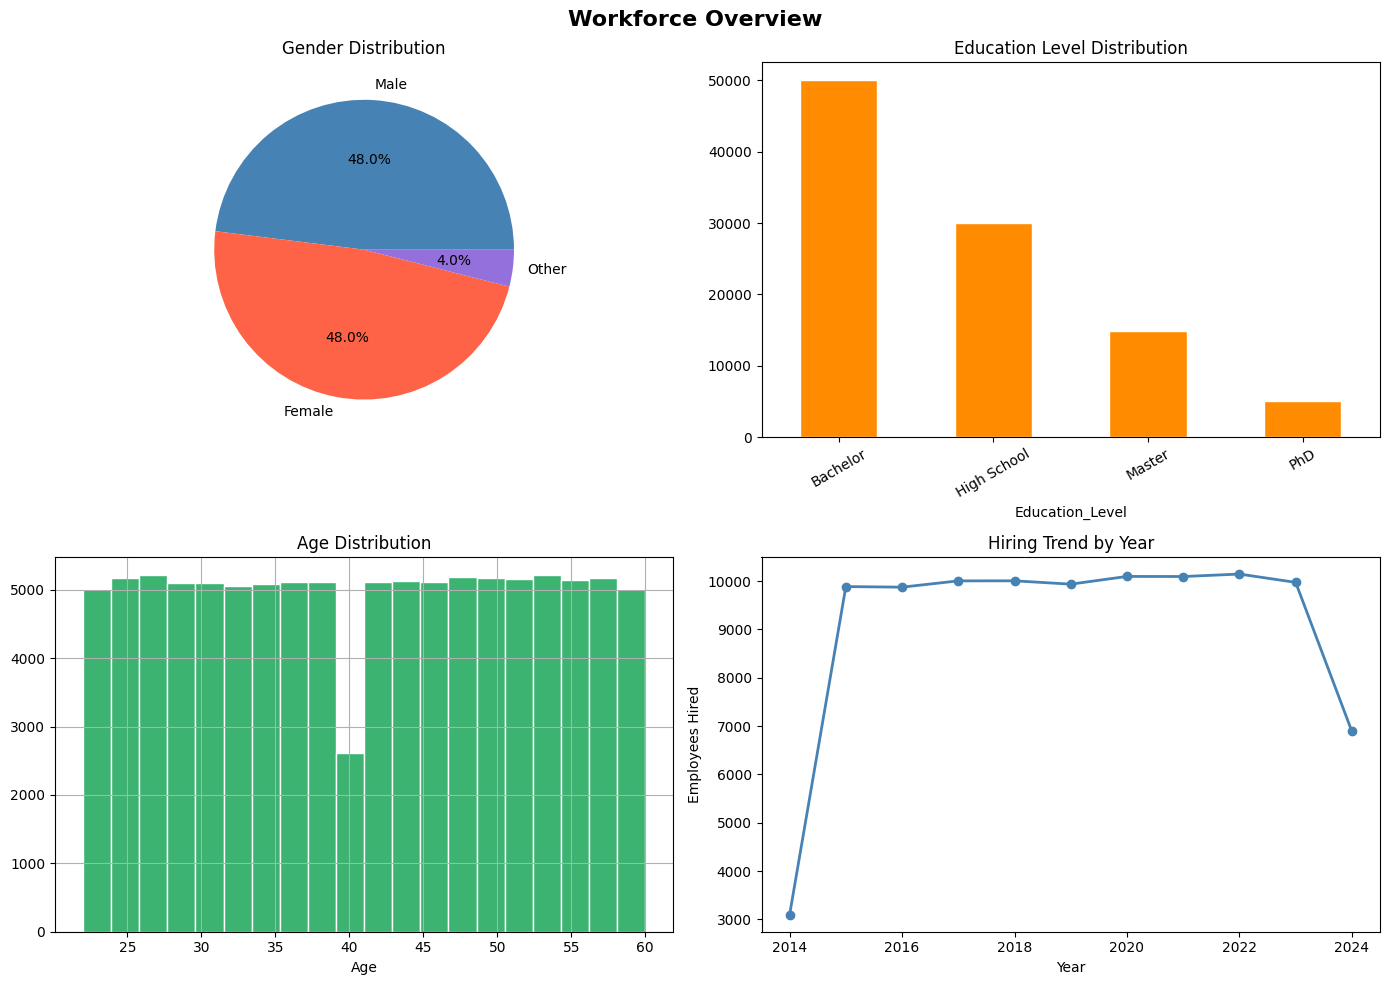

In [38]:
# Workforce Overview:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Workforce Overview', fontsize=16, fontweight='bold')

# 1. Gender Distribution
df['Gender'].value_counts().plot(
    kind='pie', ax=axes[0,0], autopct='%1.1f%%',
    colors=['steelblue','tomato','mediumpurple'])
axes[0,0].set_title('Gender Distribution')
axes[0,0].set_ylabel('')

# 2. Education Level
df['Education_Level'].value_counts().plot(
    kind='bar', ax=axes[0,1], color='darkorange', edgecolor='white')
axes[0,1].set_title('Education Level Distribution')
axes[0,1].tick_params(axis='x', rotation=30)

# 3. Age Distribution
df['Age'].hist(bins=20, ax=axes[1,0], color='mediumseagreen', edgecolor='white')
axes[1,0].set_title('Age Distribution')
axes[1,0].set_xlabel('Age')

# 4. Hiring Trend by Year
df.groupby('Hire_Year')['Employee_ID'].count().plot(
    kind='line', ax=axes[1,1], color='steelblue', marker='o', linewidth=2)
axes[1,1].set_title('Hiring Trend by Year')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('Employees Hired')

plt.tight_layout()
plt.show()